# Classical vs quantum regression

This notebook compares:

- variational quantum regression (VQR)
- ridge regression
- MLP regression

on the same synthetic regression dataset.

In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from qml.classical_baselines import run_mlp_regressor, run_ridge_regression
from qml.regression import run_vqr

## Shared configuration

In [2]:
N_SAMPLES = 200
NOISE = 0.1
TEST_SIZE = 0.25
SEED = 123

VQR_N_LAYERS = 2
VQR_STEPS = 50
VQR_STEP_SIZE = 0.1

MLP_HIDDEN_LAYER_SIZES = (32, 32)
MLP_MAX_ITER = 500

RIDGE_ALPHA = 1.0

## Run models

In [3]:
vqr_result = run_vqr(
    n_samples=N_SAMPLES,
    noise=NOISE,
    test_size=TEST_SIZE,
    seed=SEED,
    n_layers=VQR_N_LAYERS,
    steps=VQR_STEPS,
    step_size=VQR_STEP_SIZE,
    plot=False,
    save=False,
)

ridge_result = run_ridge_regression(
    n_samples=N_SAMPLES,
    noise=NOISE,
    test_size=TEST_SIZE,
    seed=SEED,
    alpha=RIDGE_ALPHA,
    plot=False,
    save=False,
)

mlp_result = run_mlp_regressor(
    n_samples=N_SAMPLES,
    noise=NOISE,
    test_size=TEST_SIZE,
    seed=SEED,
    hidden_layer_sizes=MLP_HIDDEN_LAYER_SIZES,
    max_iter=MLP_MAX_ITER,
    plot=False,
    save=False,
)

## Metric summary

In [4]:
summary = [
    {
        "model": "VQR",
        "train_mse": vqr_result["train_mse"],
        "test_mse": vqr_result["test_mse"],
        "train_mae": vqr_result["train_mae"],
        "test_mae": vqr_result["test_mae"],
    },
    {
        "model": "Ridge",
        "train_mse": ridge_result["train_mse"],
        "test_mse": ridge_result["test_mse"],
        "train_mae": ridge_result["train_mae"],
        "test_mae": ridge_result["test_mae"],
    },
    {
        "model": "MLP",
        "train_mse": mlp_result["train_mse"],
        "test_mse": mlp_result["test_mse"],
        "train_mae": mlp_result["train_mae"],
        "test_mae": mlp_result["test_mae"],
    },
]

summary

[{'model': 'VQR',
  'train_mse': 0.29700758438371283,
  'test_mse': 0.17865945115851434,
  'train_mae': 0.23254695445727222,
  'test_mae': 0.20425433701803775},
 {'model': 'Ridge',
  'train_mse': 4.490711703649848e-05,
  'test_mse': 4.315219471074882e-05,
  'train_mae': 0.00516673344748882,
  'test_mae': 0.005244853133929798},
 {'model': 'MLP',
  'train_mse': 0.0057038784522001765,
  'test_mse': 0.004103491527765519,
  'train_mae': 0.05753716767756181,
  'test_mae': 0.05229663963250704}]

In [5]:
for row in summary:
    print(
        f"{row['model']:>5} | "
        f"train MSE = {row['train_mse']:.6f} | "
        f"test MSE = {row['test_mse']:.6f} | "
        f"train MAE = {row['train_mae']:.6f} | "
        f"test MAE = {row['test_mae']:.6f}"
    )

  VQR | train MSE = 0.297008 | test MSE = 0.178659 | train MAE = 0.232547 | test MAE = 0.204254
Ridge | train MSE = 0.000045 | test MSE = 0.000043 | train MAE = 0.005167 | test MAE = 0.005245
  MLP | train MSE = 0.005704 | test MSE = 0.004103 | train MAE = 0.057537 | test MAE = 0.052297


## Inspect prediction arrays

In [6]:
x_train = np.asarray(vqr_result["x_train"], dtype=float)
x_test = np.asarray(vqr_result["x_test"], dtype=float)
y_train = np.asarray(vqr_result["y_train"], dtype=float)
y_test = np.asarray(vqr_result["y_test"], dtype=float)

x_train_plot = x_train[:, 0]
x_test_plot = x_test[:, 0]

vqr_y_test_pred = np.asarray(vqr_result["y_test_pred"], dtype=float)
ridge_y_test_pred = np.asarray(ridge_result["y_test_pred"], dtype=float)
mlp_y_test_pred = np.asarray(mlp_result["y_test_pred"], dtype=float)

## Plot training dataset

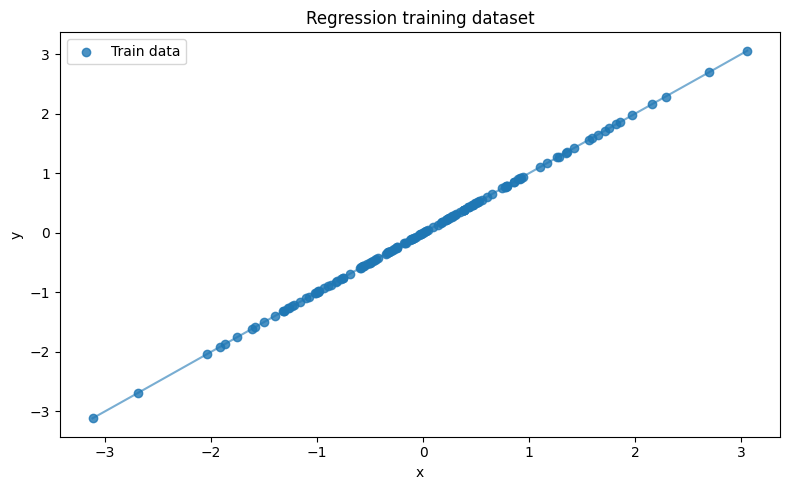

In [7]:
train_order = np.argsort(x_train_plot)

plt.figure(figsize=(8, 5))
plt.scatter(x_train_plot, y_train, alpha=0.8, label="Train data")
plt.plot(x_train_plot[train_order], y_train[train_order], alpha=0.6)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Regression training dataset")
plt.legend()
plt.tight_layout()
plt.show()

## Compare test predictions

Test targets and model predictions are plotted against the test inputs.

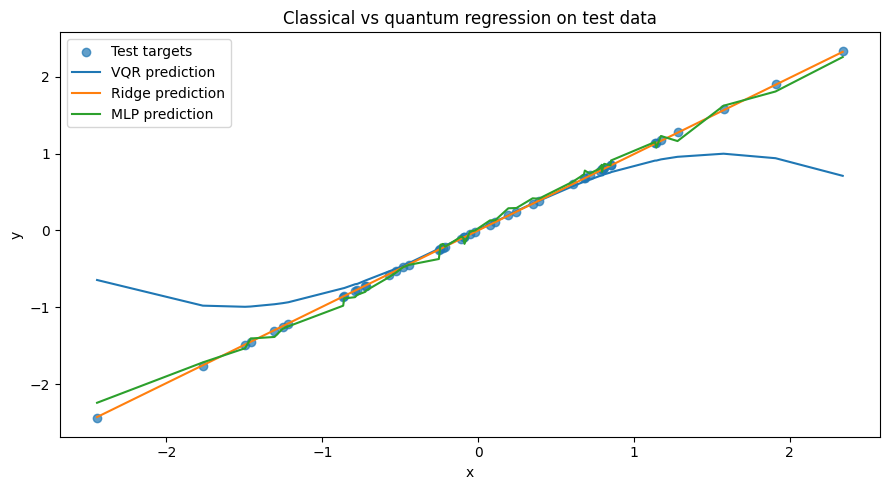

In [8]:
test_order = np.argsort(x_test_plot)
x_test_sorted = x_test_plot[test_order]
y_test_sorted = y_test[test_order]
vqr_pred_sorted = vqr_y_test_pred[test_order]
ridge_pred_sorted = ridge_y_test_pred[test_order]
mlp_pred_sorted = mlp_y_test_pred[test_order]

plt.figure(figsize=(9, 5))
plt.scatter(x_test_plot, y_test, alpha=0.7, label="Test targets")
plt.plot(x_test_sorted, vqr_pred_sorted, label="VQR prediction")
plt.plot(x_test_sorted, ridge_pred_sorted, label="Ridge prediction")
plt.plot(x_test_sorted, mlp_pred_sorted, label="MLP prediction")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Classical vs quantum regression on test data")
plt.legend()
plt.tight_layout()
plt.show()

## Predicted vs true values

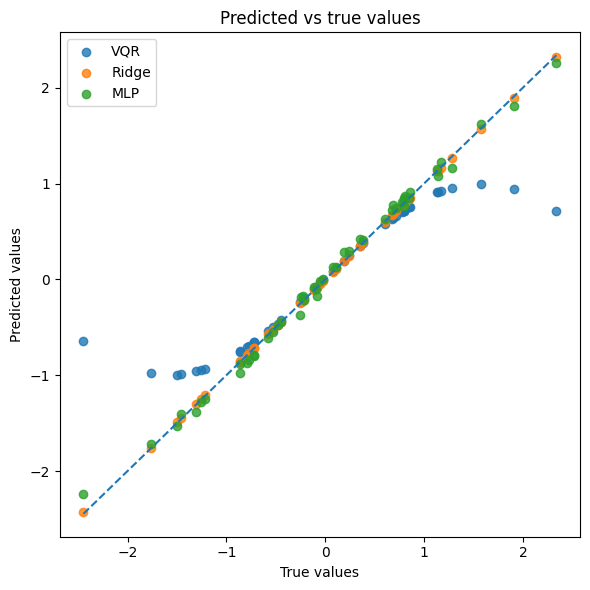

In [9]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, vqr_y_test_pred, alpha=0.8, label="VQR")
plt.scatter(y_test, ridge_y_test_pred, alpha=0.8, label="Ridge")
plt.scatter(y_test, mlp_y_test_pred, alpha=0.8, label="MLP")

lower = min(
    y_test.min(),
    vqr_y_test_pred.min(),
    ridge_y_test_pred.min(),
    mlp_y_test_pred.min(),
)
upper = max(
    y_test.max(),
    vqr_y_test_pred.max(),
    ridge_y_test_pred.max(),
    mlp_y_test_pred.max(),
)

plt.plot([lower, upper], [lower, upper], linestyle="--")
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("Predicted vs true values")
plt.legend()
plt.tight_layout()
plt.show()

## VQR loss curve

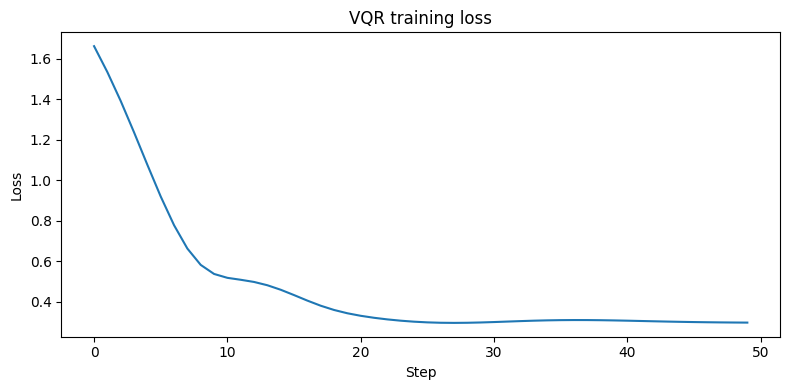

In [10]:
vqr_loss_history = np.asarray(vqr_result["loss_history"], dtype=float)

plt.figure(figsize=(8, 4))
plt.plot(vqr_loss_history)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("VQR training loss")
plt.tight_layout()
plt.show()

## MLP training loss curve

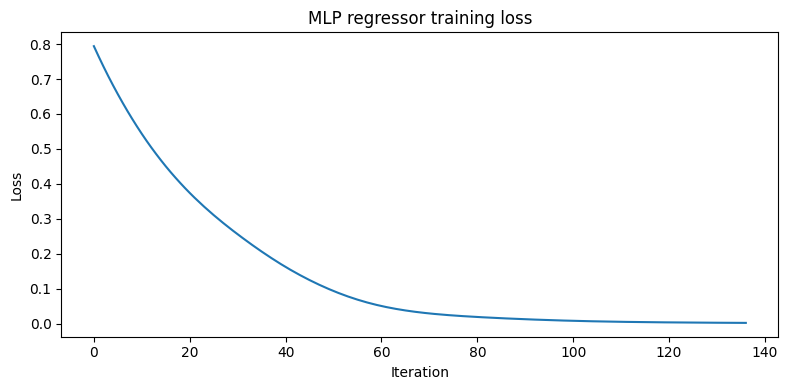

In [11]:
mlp_loss_curve = np.asarray(mlp_result["loss_curve"], dtype=float)

plt.figure(figsize=(8, 4))
plt.plot(mlp_loss_curve)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("MLP regressor training loss")
plt.tight_layout()
plt.show()

## Simple conclusion

In [12]:
best_test_mse_row = min(summary, key=lambda row: row["test_mse"])
best_test_mae_row = min(summary, key=lambda row: row["test_mae"])

print(f"Lowest test MSE: {best_test_mse_row['model']} ({best_test_mse_row['test_mse']:.6f})")
print(f"Lowest test MAE: {best_test_mae_row['model']} ({best_test_mae_row['test_mae']:.6f})")

Lowest test MSE: Ridge (0.000043)
Lowest test MAE: Ridge (0.005245)
